<a href="https://colab.research.google.com/github/Daniel211298/cmapss-turbine-rul/blob/main/DigitalTwin_NASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Twin — NASA C-MAPSS Turbofan Engine Degradation
**Objetivo:** Prever o tempo de vida restante (RUL) de turbinas usando dados de sensores.

Pipeline:
1. Carregamento e análise exploratória
2. Cálculo do RUL e seleção de sensores relevantes
3. Modelo Random Forest (baseline)
4. Modelo LSTM (deep learning temporal)

## 1. Imports e Carregamento dos Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
colunas = [
    'unit number', 'time (cicles)',
    's1', 's2', 's3',
    'm1', 'm2', 'm3', 'm4', 'm5', 'm6', 'm7', 'm8', 'm9', 'm10',
    'm11', 'm12', 'm13', 'm14', 'm15', 'm16', 'm17', 'm18', 'm19',
    'm20', 'm21', 'm22', 'm23', 'm24', 'm25', 'm26'
]

df = pd.read_csv("train_FD001.txt", sep=r'\s+', header=None, names=colunas)
df.dropna(axis=1, how='all', inplace=True)
df.head()

,unit number,time (cicles),s1,s2,s3,m1,m2,m3,m4,m5,...,m12,m13,m14,m15,m16,m17,m18,m19,m20,m21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Análise Exploratória

In [4]:
print(df.info())
print("\nValores nulos:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   unit number    20631 non-null  int64  
 1   time (cicles)  20631 non-null  int64  
 2   s1             20631 non-null  float64
 3   s2             20631 non-null  float64
 4   s3             20631 non-null  float64
 5   m1             20631 non-null  float64
 6   m2             20631 non-null  float64
 7   m3             20631 non-null  float64
 8   m4             20631 non-null  float64
 9   m5             20631 non-null  float64
 10  m6             20631 non-null  float64
 11  m7             20631 non-null  float64
 12  m8             20631 non-null  float64
 13  m9             20631 non-null  float64
 14  m10            20631 non-null  float64
 15  m11            20631 non-null  float64
 16  m12            20631 non-null  float64
 17  m13            20631 non-null  float64
 18  m14   

In [5]:
# Calcula o RUL de cada leitura
max_ciclo = df.groupby('unit number')['time (cicles)'].max()
df['max_cycle'] = df['unit number'].map(max_ciclo)
df['RUL'] = df['max_cycle'] - df['time (cicles)']
df.drop(columns=['max_cycle'], inplace=True)

# Clipa o RUL máximo em 125 (motores saudáveis no início têm RUL muito alto,
# mas o modelo não precisa distinguir entre RUL=200 e RUL=300)
df['RUL'] = df['RUL'].clip(upper=125)

df[['unit number', 'time (cicles)', 'RUL']].head(10)

,unit number,time (cicles),RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


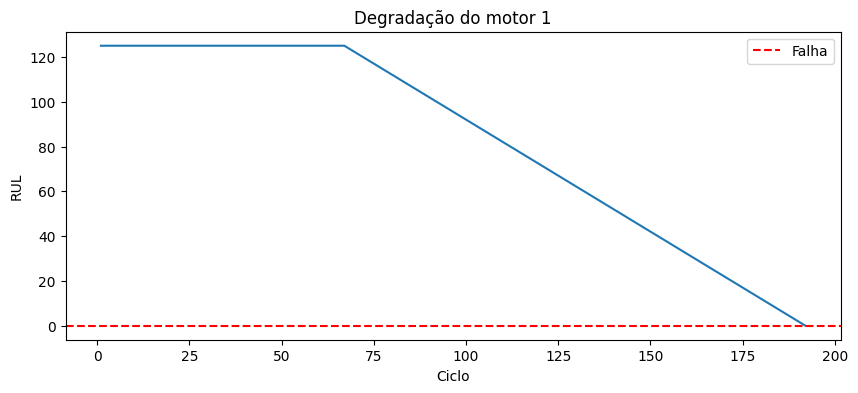

In [6]:
# Degradação de exemplo: motor 1
motor1 = df[df['unit number'] == 1].sort_values('time (cicles)')
plt.figure(figsize=(10, 4))
plt.plot(motor1['time (cicles)'], motor1['RUL'])
plt.xlabel('Ciclo')
plt.ylabel('RUL')
plt.title('Degradação do motor 1')
plt.axhline(0, color='red', linestyle='--', label='Falha')
plt.legend()
plt.show()

## 3. Seleção de Sensores por Correlação com RUL

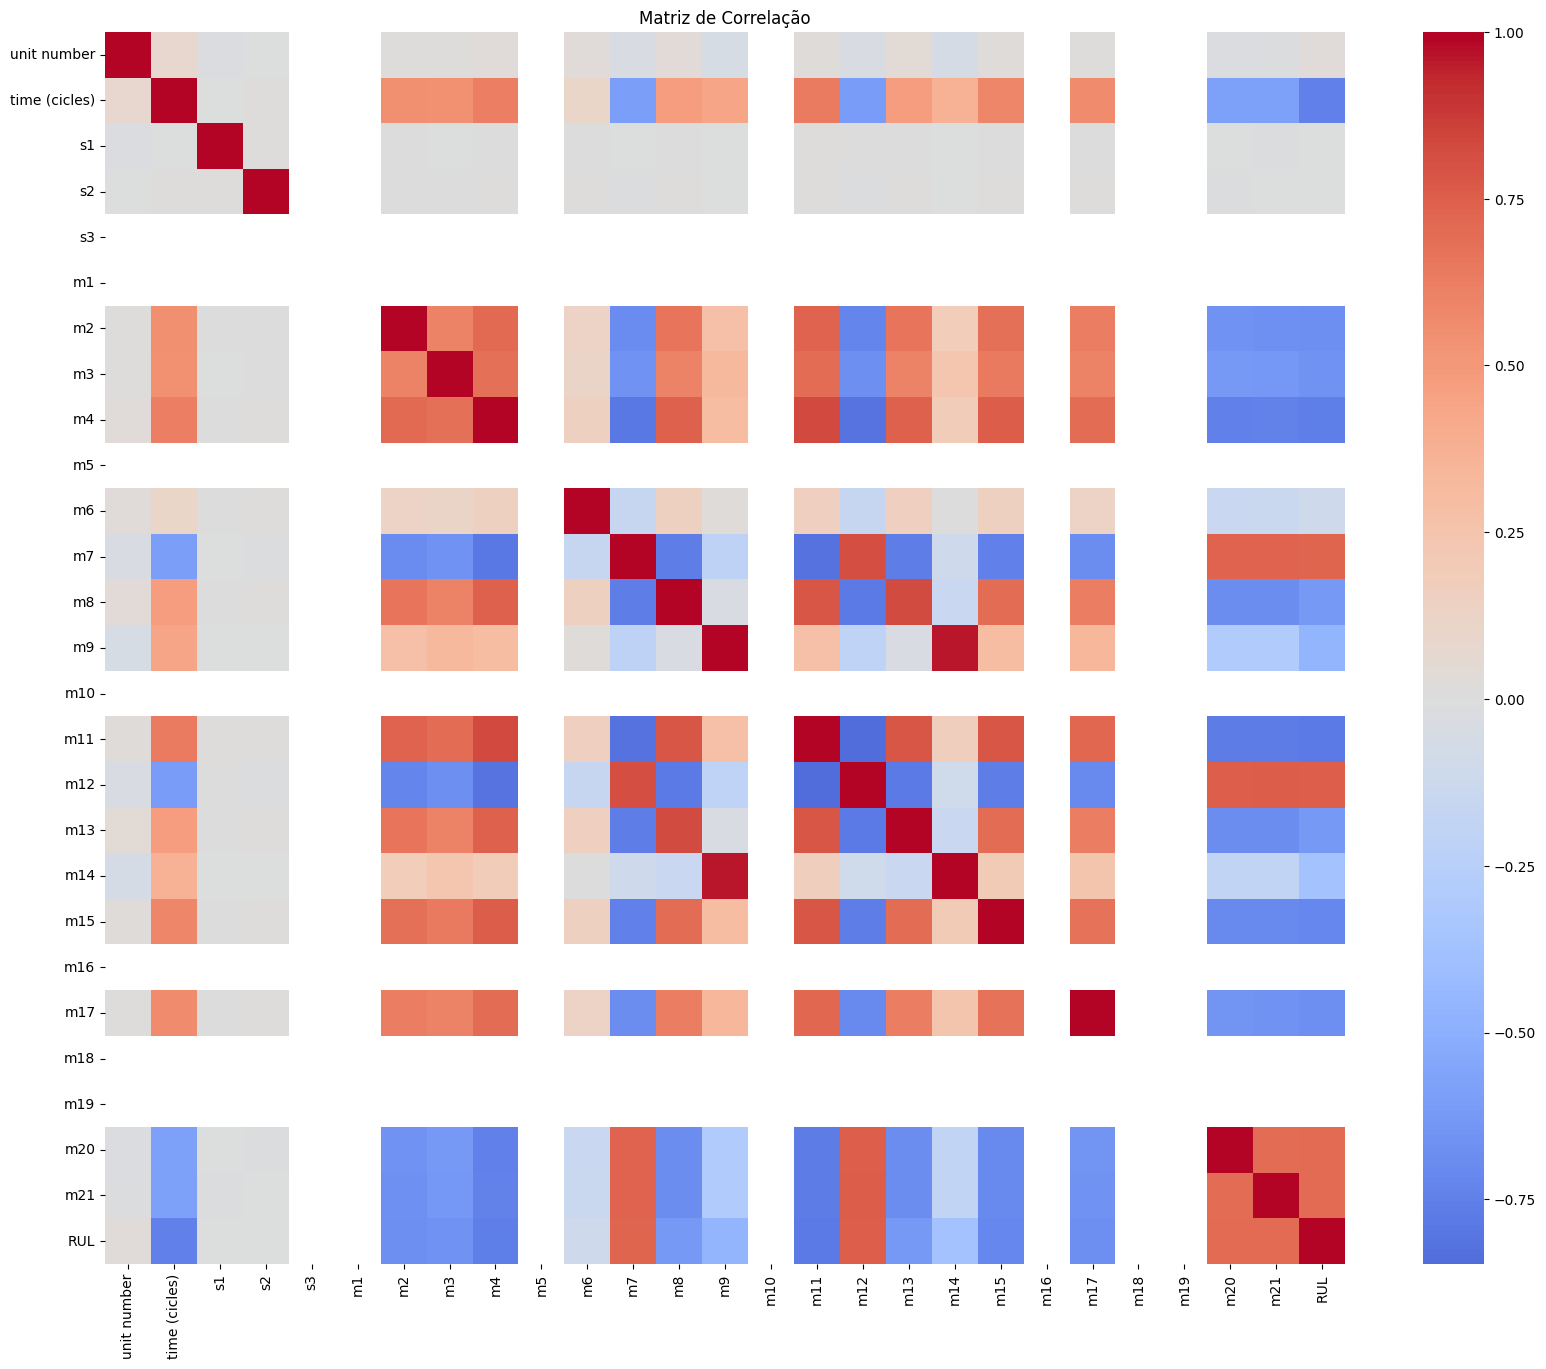

In [7]:
# Heatmap de correlação geral
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()

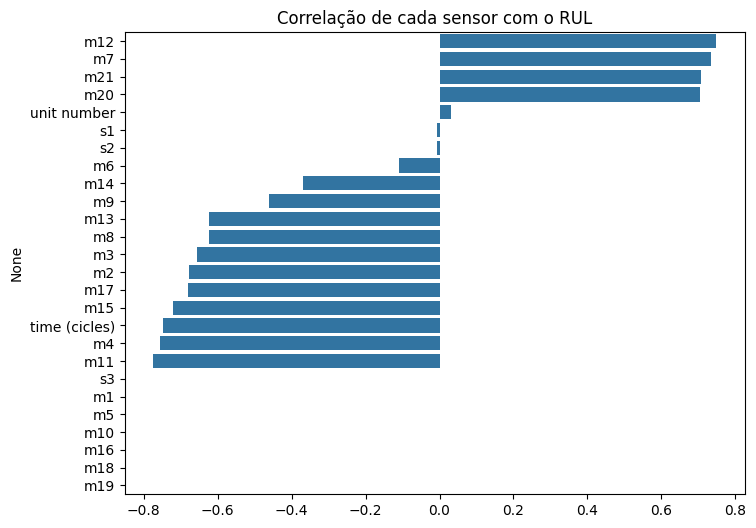

Sensores selecionados: ['m12', 'm7', 'm21', 'm20', 'm13', 'm8', 'm3', 'm2', 'm17', 'm15', 'time (cicles)', 'm4', 'm11']


In [8]:
# Correlação específica de cada sensor com o RUL
corr = df.corr(numeric_only=True)["RUL"].drop("RUL").sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Correlação de cada sensor com o RUL")
plt.show()

# Sensores mais correlacionados (|correlação| > 0.5)
sensores = corr[corr.abs() > 0.5].index.tolist()
print(f"Sensores selecionados: {sensores}")

## 4. Pré-processamento (compartilhado entre os dois modelos)

In [9]:
# Sensores escolhidos após análise de correlação
sensores = ['m4', 'm7', 'm8', 'm11', 'm12', 'm13', 'm15', 'm17', 'm20', 'm21']

# Normaliza UMA vez só — usado pelos dois modelos
scaler = MinMaxScaler()
df[sensores] = scaler.fit_transform(df[sensores])

## 5. Modelo Baseline — Random Forest
Random Forest não tem memória temporal, mas serve como baseline para comparar com o LSTM.

In [10]:
X_rf = df[sensores].values
y_rf = df['RUL'].values

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_rf, y_train_rf)

y_pred_rf = modelo_rf.predict(X_test_rf)

mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))

print(f'Random Forest — MAE: {mae_rf:.2f} ciclos | RMSE: {rmse_rf:.2f} ciclos')

Random Forest — MAE: 16.60 ciclos | RMSE: 21.82 ciclos


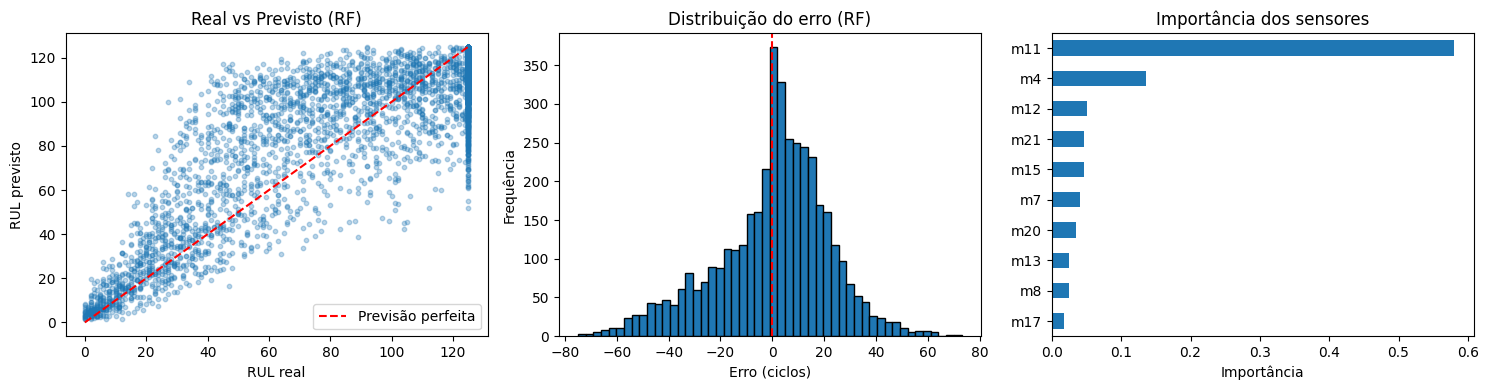

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Real vs Previsto
axes[0].scatter(y_test_rf, y_pred_rf, alpha=0.3, s=10)
axes[0].plot([0, 125], [0, 125], 'r--', label='Previsão perfeita')
axes[0].set_xlabel('RUL real')
axes[0].set_ylabel('RUL previsto')
axes[0].set_title('Real vs Previsto (RF)')
axes[0].legend()

# Distribuição do erro
erros_rf = y_test_rf - y_pred_rf
axes[1].hist(erros_rf, bins=50, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Erro (ciclos)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição do erro (RF)')

# Importância dos sensores
importancias = pd.Series(modelo_rf.feature_importances_, index=sensores)
importancias.sort_values().plot(kind='barh', ax=axes[2])
axes[2].set_title('Importância dos sensores')
axes[2].set_xlabel('Importância')

plt.tight_layout()
plt.show()

## 6. Modelo LSTM — Rede Neural Temporal
LSTM captura dependências temporais: o estado atual da turbina depende do histórico de operação.

In [12]:
def criar_janelas(dataframe, sensores, janela=30):
    """Cria sequências temporais por motor para entrada no LSTM."""
    X, y = [], []
    for unit in dataframe['unit number'].unique():
        turbina = dataframe[dataframe['unit number'] == unit].sort_values('time (cicles)')
        sensor_vals = turbina[sensores].values
        rul_vals = turbina['RUL'].values
        for i in range(len(turbina) - janela):
            X.append(sensor_vals[i:i+janela])
            y.append(rul_vals[i+janela])
    return np.array(X), np.array(y)

# Divide motores entre treino e teste (não embaralha linhas individuais)
units = df['unit number'].unique()
n_treino = int(len(units) * 0.8)
train_units = units[:n_treino]
test_units = units[n_treino:]

df_train = df[df['unit number'].isin(train_units)]
df_test = df[df['unit number'].isin(test_units)]

X_train, y_train = criar_janelas(df_train, sensores)
X_test, y_test = criar_janelas(df_test, sensores)

print(f'X_train: {X_train.shape}')  # (amostras, 30 ciclos, 10 sensores)
print(f'X_test:  {X_test.shape}')

X_train: (13738, 30, 10)
X_test:  (3893, 30, 10)


In [13]:
modelo_lstm = Sequential([
    LSTM(64, input_shape=(30, len(sensores)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

modelo_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
modelo_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5)
]

history = modelo_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,        # era 64, menor batch aprende melhor com poucos dados
    validation_data=(X_test, y_test),  # usa o teste real como validação
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
430/430 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - loss: 5844.7681 - mae: 65.5139 - val_loss: 5593.9424 - val_mae: 64.7293 - learning_rate: 0.0010
Epoch 2/200
430/430 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - loss: 4298.3042 - mae: 55.5371 - val_loss: 4239.1108 - val_mae: 56.2470 - learning_rate: 0.0010
Epoch 3/200
430/430 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - loss: 3289.5598 - mae: 48.7932 - val_loss: 3291.2595 - val_mae: 50.0412 - learning_rate: 0.0010
Epoch 4/200
430/430 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - loss: 2611.5137 - mae: 44.1460 - val_loss: 2657.5015 - val_mae: 45.6369 - learning_rate: 0.0010
Epoch 5/200
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 2208.0413 - mae: 41.2409 - val_loss: 2257.8630 - val_mae: 42.6283 - learning_rate: 0.0010
Epoch 6/200
430/430 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 1977.2029 - mae: 39.4361 - val_loss: 2024.5048 - val_mae: 40.6778 - learning_rate: 0.0010
Epoch 7/200
430/430 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 1864.6699 - mae: 38

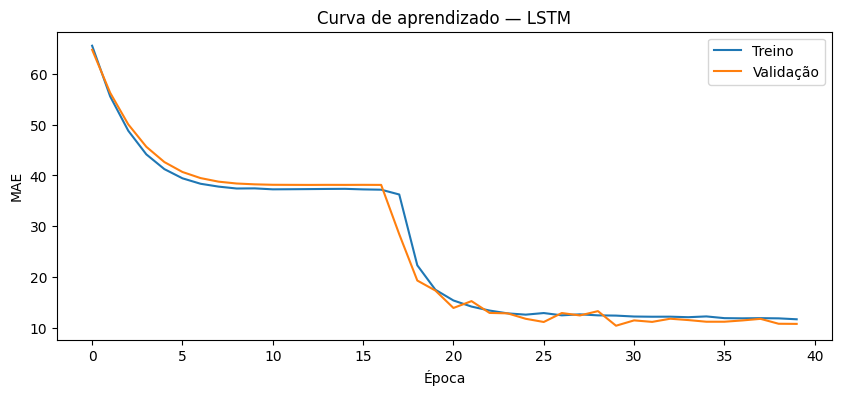

In [15]:
# Curva de aprendizado
plt.figure(figsize=(10, 4))
plt.plot(history.history['mae'], label='Treino')
plt.plot(history.history['val_mae'], label='Validação')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.title('Curva de aprendizado — LSTM')
plt.legend()
plt.show()

In [16]:
# Avalia o LSTM no conjunto de teste
y_pred_lstm = modelo_lstm.predict(X_test).flatten()

mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

print(f'LSTM        — MAE: {mae_lstm:.2f} ciclos | RMSE: {rmse_lstm:.2f} ciclos')
print(f'Random Forest — MAE: {mae_rf:.2f} ciclos | RMSE: {rmse_rf:.2f} ciclos')

122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
LSTM        — MAE: 10.44 ciclos | RMSE: 13.83 ciclos
Random Forest — MAE: 16.60 ciclos | RMSE: 21.82 ciclos


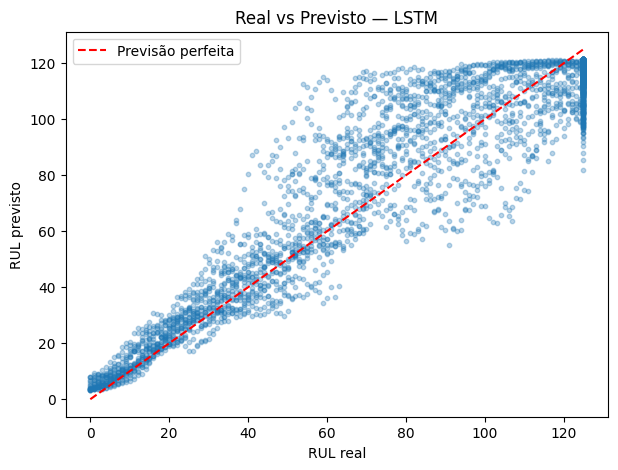

In [17]:
# Real vs Previsto — LSTM
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lstm, alpha=0.3, s=10)
plt.plot([0, 125], [0, 125], 'r--', label='Previsão perfeita')
plt.xlabel('RUL real')
plt.ylabel('RUL previsto')
plt.title('Real vs Previsto — LSTM')
plt.legend()
plt.show()